@ JeongHo SEO

From 재무비용 리서치 page, domain knowledge
### 변수선택
- 금융비용/부채
- 금융비용/총비용
- 설비투자효율 = 매출액/유형자산
- 현금흐름/총자본
- 영업이익/총자본
- 유보이익/총자본
- 자기자본비율 = 자기자본/총자산
- 자본금회전율 = 매출액/자본금
- 차입금의존도 = 차입금/총자산
- 총부채회전율 = 매출액/총부채
- 총자본투자효율 = 영업이익/총자산
- 총자본회전율 = 매출액/총자산
- 총순자산수익률 = 당기순이익/자기자본
- 현금성자산비율 = 현금및현금성자산/총자산

$\Rightarrow$ dataset이랑 용어 매칭이 온전히 되지 않아서, GPT로 정리해서 임의로 features로 삼았습니다.



### target feature
- 파산여부 ; 부도여부
- 파산(상장폐지) or 부도 == Bad

### Contents
1. Raw dataset preview
2. Input variable Selection from domain knowledge
   2.1. selected_input_features NaN 처리
3. target labeling ratio
   3.1. Case Sampling
4. Selected features
   4.1. selected input features' Correlation
   4.2. 다중공선성 기반 변수 소거
5. 5-folds & Modeling
   5.1. Random forest 기반 feature importance
6. reduced input features 대신, selected input features로 모델링 (14개 input features)
   6.1. 성능 비교

In [ ]:
! pip install pandas
! pip install sklearn.utils
! pip install numpy
! pip install matplotlib.pyplot
! pip install seaborn
! pip install matplotlib
! pip install sklearn.model_selection
! pip install sklearn.ensemble
! pip install sklearn.neural_network
! pip install sklearn.metrics

In [55]:
import pandas as pd
from sklearn.utils import resample
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib
from sklearn.model_selection import StratifiedKFold
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, roc_auc_score


### 1. Raw dataset preview

In [73]:
df = pd.read_csv('main_dataset_mod.csv')

print(df.shape)
print(df.head())
print(df.columns.to_list())

C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_11856\1713723279.py:1: DtypeWarning: Columns (260,261) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('main_dataset_mod.csv')


(163046, 265)
    Symbol  Name   결산월   회계년      주기       총자산(천원)   총자산(평균)(천원)  유동자산(천원)  \
0  A000010  조흥은행  12.0  1999  Annual  4.693918e+10  4.674953e+10       NaN   
1  A000010  조흥은행  12.0  2000  Annual  5.113869e+10  4.903894e+10       NaN   
2  A000010  조흥은행  12.0  2001  Annual  5.661012e+10  5.387440e+10       NaN   
3  A000010  조흥은행  12.0  2002  Annual  6.727043e+10  6.194027e+10       NaN   
4  A000010  조흥은행  12.0  2003  Annual  6.060160e+10  6.393601e+10       NaN   

   당좌자산(천원)  현금및현금성자산(천원)  ...  현금흐름(연율화)(천원)  현금흐름(직전4분기)(천원)  현금흐름(보통)(천원)  \
0       NaN  1.210399e+09  ...   -746322000.0              NaN  -746322000.0   
1       NaN  9.738450e+08  ...     99359000.0              NaN    99359000.0   
2       NaN  1.346084e+09  ...    710634000.0              NaN   710634000.0   
3       NaN  1.174976e+09  ...   -395695000.0              NaN  -395695000.0   
4       NaN  9.181470e+08  ...   -750930000.0              NaN  -750930000.0   

   현금흐름(보통,연율화)(천원)  현금흐름(보통,직전4분기)(

### 2. Input variable Selection from domain knowledge

In [62]:
# 1. 금융비용/부채
df['금융비용/부채'] = np.where(
    df['총부채(천원)'] != 0,
    df['이자비용(비영업)(천원)'] / df['총부채(천원)'],
    np.nan
)

# 2. 금융비용/총비용
total_cost = df['매출원가(천원)'] + df['판매비와관리비(천원)']
df['금융비용/총비용'] = np.where(
    total_cost != 0,
    df['이자비용(비영업)(천원)'] / total_cost,
    np.nan
)

# 3. 설비투자효율
df['설비투자효율'] = np.where(
    df['유형자산(천원)'] != 0,
    df['매출액(천원)'] / df['유형자산(천원)'],
    np.nan
)

# 4. 현금흐름/총자본
df['현금흐름/총자본'] = np.where(
    df['총자본(천원)'] != 0,
    df['영업활동으로인한현금흐름(천원)'] / df['총자본(천원)'],
    np.nan
)

# 5. 영업이익/총자본
df['영업이익/총자본'] = np.where(
    df['총자본(천원)'] != 0,
    df['영업이익(천원)'] / df['총자본(천원)'],
    np.nan
)

# 6. 유보이익/총자본
df['유보이익/총자본'] = np.where(
    df['총자본(천원)'] != 0,
    df['이익잉여금(천원)'] / df['총자본(천원)'],
    np.nan
)

# 7. 자기자본비율
df['자기자본비율'] = np.where(
    df['총자산(천원)'] != 0,
    df['총자본(천원)'] / df['총자산(천원)'],
    np.nan
)

# 8. 자본금회전율
df['자본금회전율'] = np.where(
    df['자본금(천원)'] != 0,
    df['매출액(천원)'] / df['자본금(천원)'],
    np.nan
)

# 9. 차입금의존도
total_loans = df['단기차입금(천원)'] + df['장기차입금(천원)']
df['차입금의존도'] = np.where(
    df['총자산(천원)'] != 0,
    total_loans / df['총자산(천원)'],
    np.nan
)

# 10. 총부채회전율
df['총부채회전율'] = np.where(
    df['총부채(천원)'] != 0,
    df['매출액(천원)'] / df['총부채(천원)'],
    np.nan
)

# 11. 총자본투자효율
df['총자본투자효율'] = np.where(
    df['총자산(천원)'] != 0,
    df['영업이익(천원)'] / df['총자산(천원)'],
    np.nan
)

# 12. 총자본회전율
df['총자본회전율'] = np.where(
    df['총자산(천원)'] != 0,
    df['매출액(천원)'] / df['총자산(천원)'],
    np.nan
)

# 13. 총순자산수익률
df['총순자산수익률'] = np.where(
    df['총자본(천원)'] != 0,
    df['당기순이익(천원)'] / df['총자본(천원)'],
    np.nan
)

# 14. 현금성자산비율
df['현금성자산비율'] = np.where(
    df['총자산(천원)'] != 0,
    df['현금및현금성자산(천원)'] / df['총자산(천원)'],
    np.nan
)


selected_input_features = [
    '금융비용/부채',
    '금융비용/총비용',
    '설비투자효율',
    '현금흐름/총자본',
    '영업이익/총자본',
    '유보이익/총자본',
    '자기자본비율',
    '자본금회전율',
    '차입금의존도',
    '총부채회전율',
    '총자본투자효율',
    '총자본회전율',
    '총순자산수익률',
    '현금성자산비율'
]


target_features = [
    '파산여부',
    '부도여부',
    'Bad'
]

df_selected = df[selected_input_features + target_features]

### 2.1. selected_input_features NaN 처리

In [63]:
print("selected features:")
print(df_selected.columns.tolist())
print(df_selected.shape)


na_count = df_selected.isna().sum()
na_ratio = df_selected.isna().mean()

na_summary = pd.DataFrame({
    '결측값 개수': na_count,
    '결측값 비율': na_ratio
})

na_summary['결측값 비율'] = (na_summary['결측값 비율'] * 100).round(2).astype(str) + '%'

print(na_summary)


selected features:
['금융비용/부채', '금융비용/총비용', '설비투자효율', '현금흐름/총자본', '영업이익/총자본', '유보이익/총자본', '자기자본비율', '자본금회전율', '차입금의존도', '총부채회전율', '총자본투자효율', '총자본회전율', '총순자산수익률', '현금성자산비율', '파산여부', '부도여부', 'Bad']
(163046, 17)
          결측값 개수  결측값 비율
금융비용/부채    62835  38.54%
금융비용/총비용   65896  40.42%
설비투자효율     63896  39.19%
현금흐름/총자본   62826  38.53%
영업이익/총자본   62826  38.53%
유보이익/총자본   62826  38.53%
자기자본비율     62825  38.53%
자본금회전율     62831  38.54%
차입금의존도     69730  42.77%
총부채회전율     62835  38.54%
총자본투자효율    62825  38.53%
총자본회전율     62825  38.53%
총순자산수익률    62826  38.53%
현금성자산비율    62825  38.53%
파산여부           0    0.0%
부도여부           0    0.0%
Bad            0    0.0%


- input feature의 결측치 비율이 40% 정도이므로, 평균으로 결측치 채워넣기 (continuous variable 이므로)
- target feature: 결측치 없음

In [75]:
df_selected[selected_input_features] = df_selected[selected_input_features].fillna(df_selected[selected_input_features].mean())

print("selected input features 결측치 check:\n")
print(df_selected[selected_input_features].isna().sum())
print((df_selected[selected_input_features].isna().mean() * 100).round(2).astype(str) + '%')


selected input features 결측치 check:

금융비용/부채     0
금융비용/총비용    0
설비투자효율      0
현금흐름/총자본    0
영업이익/총자본    0
유보이익/총자본    0
자기자본비율      0
자본금회전율      0
차입금의존도      0
총부채회전율      0
총자본투자효율     0
총자본회전율      0
총순자산수익률     0
현금성자산비율     0
dtype: int64
금융비용/부채     0.0%
금융비용/총비용    0.0%
설비투자효율      0.0%
현금흐름/총자본    0.0%
영업이익/총자본    0.0%
유보이익/총자본    0.0%
자기자본비율      0.0%
자본금회전율      0.0%
차입금의존도      0.0%
총부채회전율      0.0%
총자본투자효율     0.0%
총자본회전율      0.0%
총순자산수익률     0.0%
현금성자산비율     0.0%
dtype: object


### 3. target labeling ratio

In [76]:
for target in target_features:
    print(f'--- {target} ---')
    counts = df_selected[target].value_counts(normalize=True).sort_index()
    for label, ratio in counts.items():
        print(f'Label {label}: {ratio:.2%}')
    print()


--- 파산여부 ---
Label 0: 99.94%
Label 1: 0.06%

--- 부도여부 ---
Label 0: 98.82%
Label 1: 1.18%

--- Bad ---
Label 0: 98.76%
Label 1: 1.24%



### 3.1. Case Sampling
- 파산(상장폐지)이 극소수이고 부도가 대다수이므로, 파산을 제외하여 부도만을 check해도 좋을 것 같습니다.
- 아래부터는 Bad를 기준으로 모델링했습니다.
- 그냥 0으로 무지성 예측해도 98.76% 정확도가 나와서, case sampling을 했습니다. (under sampling: 1 label을 random하게 sampling)

In [77]:
df_majority = df_selected[df_selected['Bad'] == 0]
df_minority = df_selected[df_selected['Bad'] == 1]

df_majority_downsampled = df_majority.sample(n=len(df_minority), random_state=42)

df_balanced = pd.concat([df_majority_downsampled, df_minority])

df_balanced = df_balanced.sample(frac=1, random_state=42).reset_index(drop=True)

print(df_balanced['Bad'].value_counts())
print(df_balanced['Bad'].value_counts(normalize=True).sort_index())

Bad
0    2028
1    2028
Name: count, dtype: int64
Bad
0    0.5
1    0.5
Name: proportion, dtype: float64


### 4. Selected features

In [78]:
X = df_balanced[selected_input_features]
y = df_balanced['Bad']

display(X.head())
print(y.value_counts())

,금융비용/부채,금융비용/총비용,설비투자효율,현금흐름/총자본,영업이익/총자본,유보이익/총자본,자기자본비율,자본금회전율,차입금의존도,총부채회전율,총자본투자효율,총자본회전율,총순자산수익률,현금성자산비율
0,0.021624,0.009514,2.818623,0.254692,0.137096,0.720578,0.435138,23.373632,0.289470,2.378480,0.059656,1.343513,0.138131,0.122560
1,0.012302,0.004457,2.320307,0.223734,0.147512,1.033912,0.739368,223.565852,0.046862,3.178935,0.109066,0.828532,0.106446,0.093471
2,0.029002,0.165162,276.586878,0.079133,0.022176,-0.322794,0.319256,1854.110708,0.246983,2.277247,0.020935,0.885445,-0.097917,0.084627
3,0.029002,0.165162,276.586878,0.079133,0.022176,-0.322794,0.319256,1854.110708,0.246983,2.277247,0.020935,0.885445,-0.097917,0.084627
4,0.032812,0.122399,0.054832,0.540141,0.574706,1.572820,-0.812393,0.088390,0.077109,0.010468,-0.466887,0.018973,0.709760,0.006271


Bad
0    2028
1    2028
Name: count, dtype: int64


### 4.1. selected input features' Correlation

           금융비용/부채  금융비용/총비용    설비투자효율  현금흐름/총자본  영업이익/총자본  유보이익/총자본  \
금융비용/부채   1.000000  0.053116 -0.116488  0.001683 -0.024423 -0.009161   
금융비용/총비용  0.053116  1.000000  0.013006  0.000213 -0.000752  0.006328   
설비투자효율   -0.116488  0.013006  1.000000  0.024834 -0.005154 -0.012643   
현금흐름/총자본  0.001683  0.000213  0.024834  1.000000 -0.151527 -0.028978   
영업이익/총자본 -0.024423 -0.000752 -0.005154 -0.151527  1.000000  0.486840   
유보이익/총자본 -0.009161  0.006328 -0.012643 -0.028978  0.486840  1.000000   
자기자본비율   -0.058133 -0.876296 -0.017226  0.003261 -0.000337 -0.004917   
자본금회전율   -0.118805 -0.010255  0.924776  0.030150 -0.002106  0.007611   
차입금의존도    0.044538  0.806040  0.013726 -0.003749  0.003178  0.007969   
총부채회전율   -0.107461 -0.046413  0.149371  0.016059  0.026042  0.049787   
총자본투자효율  -0.199489 -0.017743  0.058522  0.104295  0.151444  0.126929   
총자본회전율    0.128769 -0.024230  0.031439 -0.072841  0.016516  0.029762   
총순자산수익률  -0.010061  0.001608 -0.002667 -0.135703  0.838475  0.43

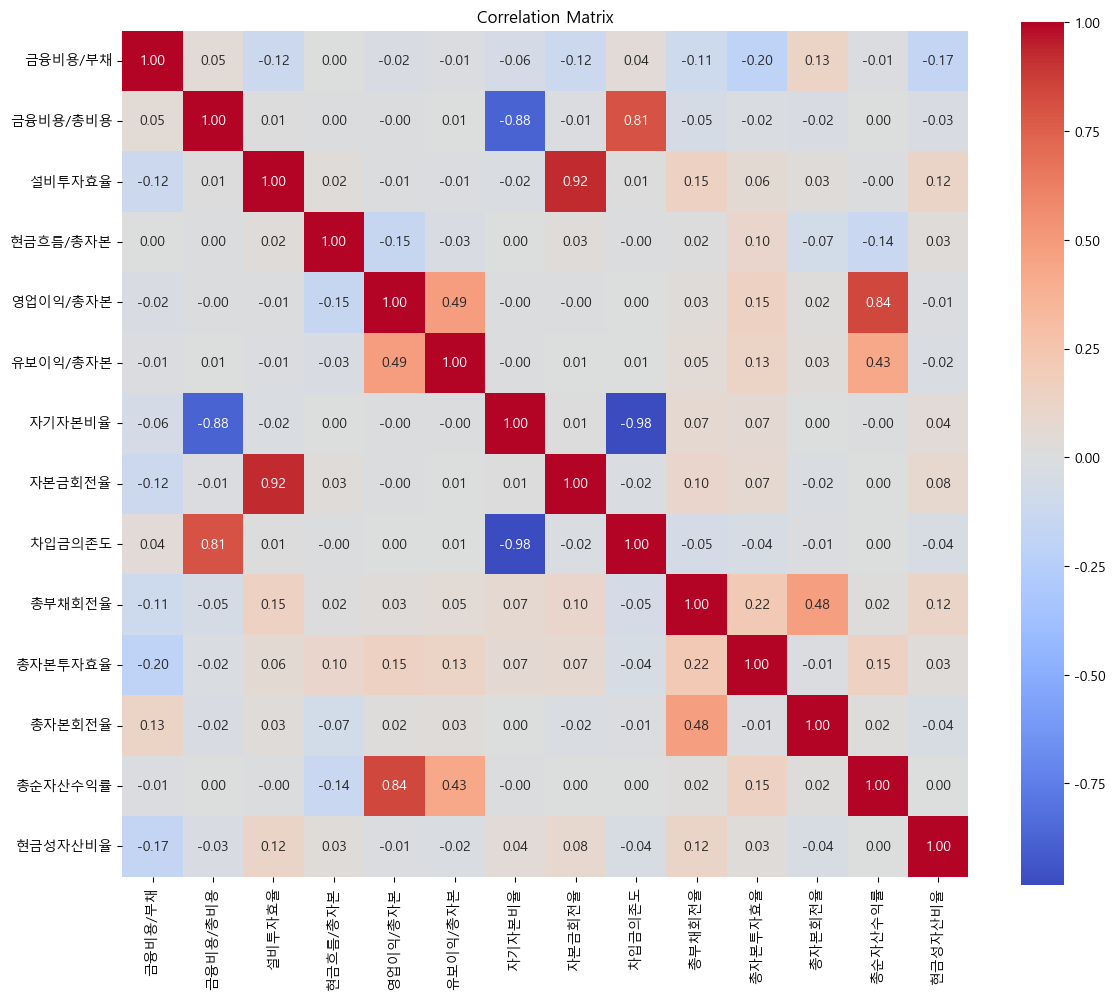

In [79]:
correlation_matrix = X.corr()  # 기본값: Pearson correlation
print(correlation_matrix)

# font
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# Heat map
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap='coolwarm', square=True)
plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

### 4.2. 다중공선성 기반 변수 소거
- correlation > 0.8인 경우 소거

reduced input features list:
['자기자본비율', '자본금회전율', '차입금의존도', '총순자산수익률']

input features change:
(4056, 14)
(4056, 10)
_____________
           금융비용/부채  금융비용/총비용    설비투자효율  현금흐름/총자본  영업이익/총자본  유보이익/총자본  \
금융비용/부채   1.000000  0.053116 -0.116488  0.001683 -0.024423 -0.009161   
금융비용/총비용  0.053116  1.000000  0.013006  0.000213 -0.000752  0.006328   
설비투자효율   -0.116488  0.013006  1.000000  0.024834 -0.005154 -0.012643   
현금흐름/총자본  0.001683  0.000213  0.024834  1.000000 -0.151527 -0.028978   
영업이익/총자본 -0.024423 -0.000752 -0.005154 -0.151527  1.000000  0.486840   
유보이익/총자본 -0.009161  0.006328 -0.012643 -0.028978  0.486840  1.000000   
총부채회전율   -0.107461 -0.046413  0.149371  0.016059  0.026042  0.049787   
총자본투자효율  -0.199489 -0.017743  0.058522  0.104295  0.151444  0.126929   
총자본회전율    0.128769 -0.024230  0.031439 -0.072841  0.016516  0.029762   
현금성자산비율  -0.165153 -0.029658  0.117864  0.027391 -0.009407 -0.021785   

            총부채회전율   총자본투자효율    총자본회전율   현금성자산비율  
금융비용/부채  -0.107461 -0.199

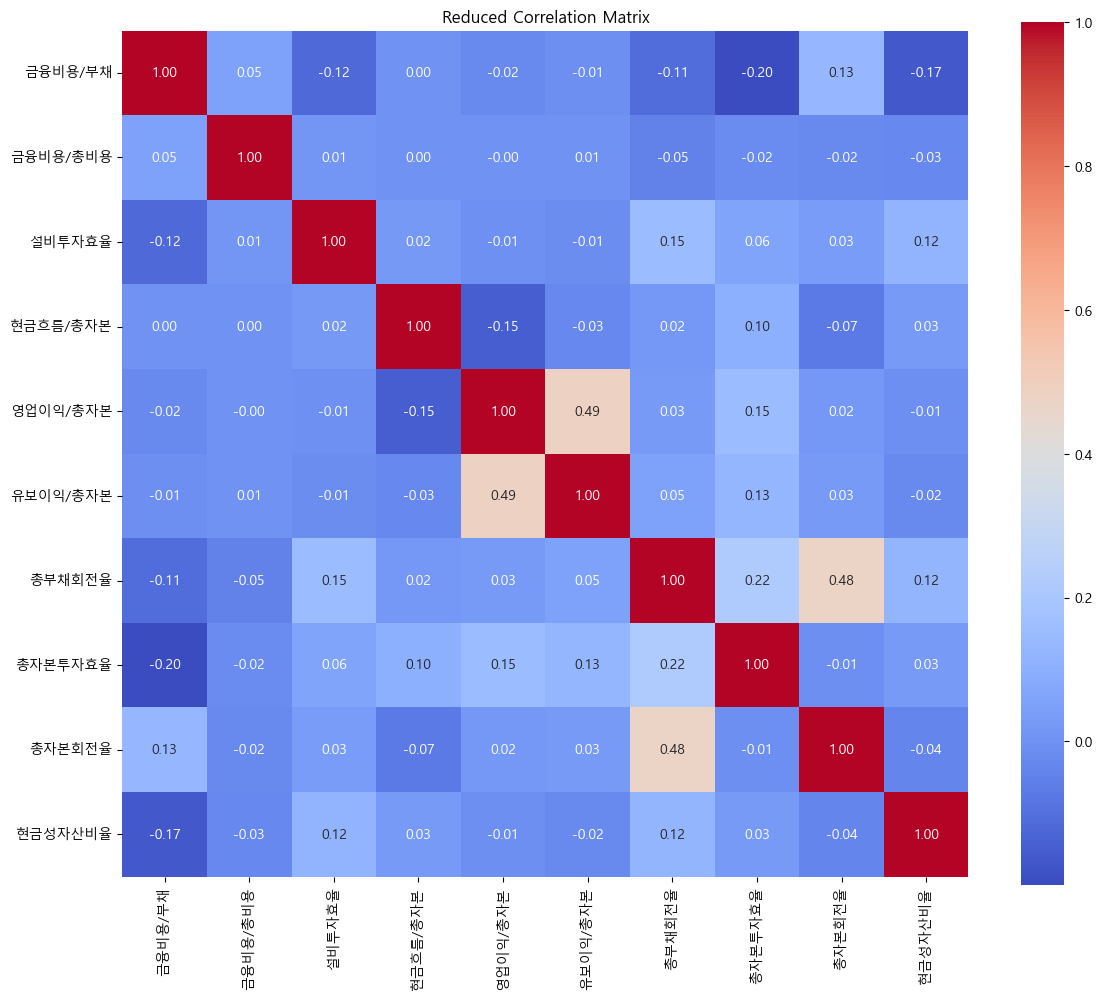

In [80]:
corr_matrix = X.corr().abs()

upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

to_drop = [column for column in upper.columns if any(upper[column] > 0.8)]

print("reduced input features list:")
print(to_drop)

X_reduced = X.drop(columns=to_drop)

print("\ninput features change:")
print(X.shape)
print(X_reduced.shape)

print('_____________')
reduced_correlation_matrix = X_reduced.corr()
print(reduced_correlation_matrix)

# font
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# Heat map
plt.figure(figsize=(12, 10))
sns.heatmap(reduced_correlation_matrix, annot=True, fmt=".2f", cmap='coolwarm', square=True)
plt.title("Reduced Correlation Matrix")
plt.tight_layout()
plt.show()

### 5. 5-folds & Modeling
Reduced input features로 5-folds cross validation
- Random Forest
- Adaboost
- MLP (Deep Learning)
- Ensemble (Voting)

In [84]:
# 1. 모델 정의
models = {
    'RandomForest': RandomForestClassifier(random_state=42),
    'AdaBoost': AdaBoostClassifier(random_state=42),
    'MLP': MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=500, random_state=42)
}

# 2. 결과 저장 딕셔너리
results = {model_name: {'accuracy': [], 'roc_auc': []} for model_name in models}
results['VotingEnsemble'] = {'accuracy': [], 'roc_auc': []}

# 3. 5-Fold 설정
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# 4. 교차검증 루프
for fold, (train_idx, val_idx) in enumerate(skf.split(X_reduced, y)):
    print(f"\n📂 Fold {fold+1}")
    
    X_train, X_val = X_reduced.iloc[train_idx], X_reduced.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]
    
    proba_list = []  # voting용 예측 확률 모음

    for model_name, model in models.items():
        model.fit(X_train, y_train)
        y_pred = model.predict(X_val)
        y_proba = model.predict_proba(X_val)[:, 1]
        
        # 개별 성능 기록
        acc = accuracy_score(y_val, y_pred)
        auc = roc_auc_score(y_val, y_proba)
        results[model_name]['accuracy'].append(acc)
        results[model_name]['roc_auc'].append(auc)
        
        print(f"{model_name:13s} | Accuracy: {acc:.4f} | ROC AUC: {auc:.4f}")
        
        # Voting용 확률 저장
        proba_list.append(y_proba)
    
    # Soft Voting Ensemble
    avg_proba = np.mean(proba_list, axis=0)
    y_voting = (avg_proba >= 0.5).astype(int)
    
    acc_voting = accuracy_score(y_val, y_voting)
    auc_voting = roc_auc_score(y_val, avg_proba)
    
    results['VotingEnsemble']['accuracy'].append(acc_voting)
    results['VotingEnsemble']['roc_auc'].append(auc_voting)
    
    print(f"{'VotingEnsemble':13s} | Accuracy: {acc_voting:.4f} | ROC AUC: {auc_voting:.4f}")

# 5. 평균 성능 요약
print("\n📊 평균 성능 요약:")
for model_name in results:
    acc_avg = np.mean(results[model_name]['accuracy'])
    auc_avg = np.mean(results[model_name]['roc_auc'])
    print(f"{model_name:13s} | 평균 정확도: {acc_avg:.4f} | 평균 ROC AUC: {auc_avg:.4f}")



📂 Fold 1
RandomForest  | Accuracy: 0.6761 | ROC AUC: 0.7014
AdaBoost      | Accuracy: 0.6601 | ROC AUC: 0.6820
MLP           | Accuracy: 0.6515 | ROC AUC: 0.6777
VotingEnsemble | Accuracy: 0.6650 | ROC AUC: 0.6950

📂 Fold 2
RandomForest  | Accuracy: 0.6856 | ROC AUC: 0.7254
AdaBoost      | Accuracy: 0.6695 | ROC AUC: 0.7044
MLP           | Accuracy: 0.6732 | ROC AUC: 0.6958
VotingEnsemble | Accuracy: 0.7004 | ROC AUC: 0.7181

📂 Fold 3
RandomForest  | Accuracy: 0.6757 | ROC AUC: 0.7128
AdaBoost      | Accuracy: 0.6510 | ROC AUC: 0.6827
MLP           | Accuracy: 0.6461 | ROC AUC: 0.6808
VotingEnsemble | Accuracy: 0.6683 | ROC AUC: 0.7078

📂 Fold 4
RandomForest  | Accuracy: 0.6856 | ROC AUC: 0.7192
AdaBoost      | Accuracy: 0.6658 | ROC AUC: 0.7058
MLP           | Accuracy: 0.6695 | ROC AUC: 0.7006
VotingEnsemble | Accuracy: 0.6856 | ROC AUC: 0.7246

📂 Fold 5
RandomForest  | Accuracy: 0.6720 | ROC AUC: 0.6904
AdaBoost      | Accuracy: 0.6597 | ROC AUC: 0.6781
MLP           | Accuracy: 0.

### 5.1. Random forest 기반 feature importance

C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_11856\1170696816.py:20: UserWarning: Glyph 128204 (\N{PUSHPIN}) missing from font(s) Malgun Gothic.
  plt.tight_layout()
c:\Users\HOME\Desktop\VSC\2025_spring_Data_Mining\DM_env\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128204 (\N{PUSHPIN}) missing from font(s) Malgun Gothic.
  fig.canvas.print_figure(bytes_io, **kw)


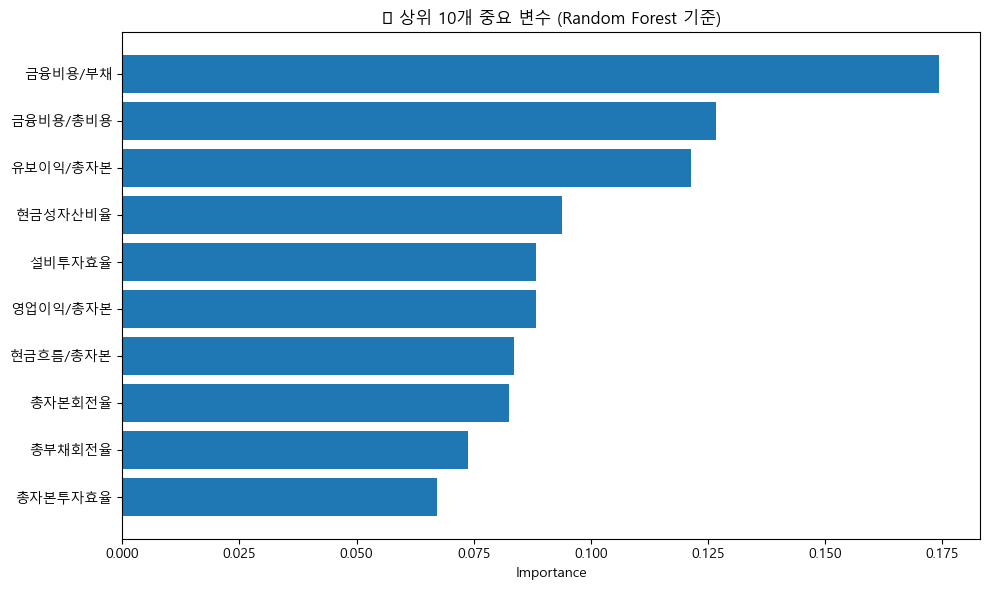

In [85]:
# 1. RandomForest 학습 (전체 데이터 사용)
rf = RandomForestClassifier(random_state=42)
rf.fit(X_reduced, y)

# 2. 중요도 추출
importances = rf.feature_importances_
feature_names = X_reduced.columns

# 3. 중요도 정리
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# 4. 상위 중요 변수 시각화
plt.figure(figsize=(10, 6))
plt.barh(importance_df['Feature'][:10][::-1], importance_df['Importance'][:10][::-1])
plt.title("📌 상위 10개 중요 변수 (Random Forest 기준)")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

- 10가지 reduced input features모두 비슷하게 중요한 것 같습니다.
- 성능이 그렇게 좋게 나오지 못해서, 변수 선택이 유의미한지 잘 모르겠네요..

### 6. reduced input features 대신, selected input features로 모델링 (14개 input features)

In [86]:
# Recall
# X = df_balanced[selected_input_features]
# y = df_balanced['Bad']


# Stratified K-Fold 5 분할
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# 모델 정의
models = {
    'RandomForest': RandomForestClassifier(random_state=42),
    'AdaBoost': AdaBoostClassifier(random_state=42),
    'DNN': MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=500, random_state=42)
}

# 결과 저장용 딕셔너리
results = {model_name: {'accuracy': [], 'roc_auc': []} for model_name in models}
results['VotingEnsemble'] = {'accuracy': [], 'roc_auc': []}

# K-Fold 루프
for fold, (train_idx, val_idx) in enumerate(skf.split(X, y)):
    print(f"\n📂 Fold {fold+1}")
    
    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]
    
    proba_list = []  # 각 모델 확률 저장 (앙상블용)

    for model_name, model in models.items():
        model.fit(X_train, y_train)
        y_pred = model.predict(X_val)
        y_proba = model.predict_proba(X_val)[:, 1]

        acc = accuracy_score(y_val, y_pred)
        auc = roc_auc_score(y_val, y_proba)

        results[model_name]['accuracy'].append(acc)
        results[model_name]['roc_auc'].append(auc)

        print(f"{model_name:13s} | Accuracy: {acc:.4f} | ROC AUC: {auc:.4f}")
        proba_list.append(y_proba)

    # Soft Voting Ensemble (평균 확률)
    avg_proba = np.mean(proba_list, axis=0)
    y_voting = (avg_proba >= 0.5).astype(int)

    acc_voting = accuracy_score(y_val, y_voting)
    auc_voting = roc_auc_score(y_val, avg_proba)

    results['VotingEnsemble']['accuracy'].append(acc_voting)
    results['VotingEnsemble']['roc_auc'].append(auc_voting)

    print(f"VotingEnsemble  | Accuracy: {acc_voting:.4f} | ROC AUC: {auc_voting:.4f}")

# 평균 성능 요약
print("\n📊 평균 성능 요약 (전체 X):")
for model_name in results:
    avg_acc = np.mean(results[model_name]['accuracy'])
    avg_auc = np.mean(results[model_name]['roc_auc'])
    print(f"{model_name:13s} | 평균 정확도: {avg_acc:.4f} | 평균 ROC AUC: {avg_auc:.4f}")



📂 Fold 1
RandomForest  | Accuracy: 0.6823 | ROC AUC: 0.7079
AdaBoost      | Accuracy: 0.6650 | ROC AUC: 0.6822
DNN           | Accuracy: 0.6342 | ROC AUC: 0.6709
VotingEnsemble  | Accuracy: 0.6761 | ROC AUC: 0.6987

📂 Fold 2
RandomForest  | Accuracy: 0.6856 | ROC AUC: 0.7235
AdaBoost      | Accuracy: 0.6683 | ROC AUC: 0.7009
DNN           | Accuracy: 0.6178 | ROC AUC: 0.6598
VotingEnsemble  | Accuracy: 0.6769 | ROC AUC: 0.6972

📂 Fold 3
RandomForest  | Accuracy: 0.6831 | ROC AUC: 0.7213
AdaBoost      | Accuracy: 0.6535 | ROC AUC: 0.6789
DNN           | Accuracy: 0.6387 | ROC AUC: 0.6611
VotingEnsemble  | Accuracy: 0.6732 | ROC AUC: 0.6920

📂 Fold 4
RandomForest  | Accuracy: 0.6991 | ROC AUC: 0.7371
AdaBoost      | Accuracy: 0.6634 | ROC AUC: 0.7016
DNN           | Accuracy: 0.5092 | ROC AUC: 0.4519
VotingEnsemble  | Accuracy: 0.5746 | ROC AUC: 0.7148

📂 Fold 5
RandomForest  | Accuracy: 0.6745 | ROC AUC: 0.7111
AdaBoost      | Accuracy: 0.6547 | ROC AUC: 0.6809
DNN           | Accuracy

- 마찬가지로 안좋게 나왔네요..

### 6.1. 성능 비교

In [87]:
# 모델 정의
models = {
    'RandomForest': RandomForestClassifier(random_state=42),
    'AdaBoost': AdaBoostClassifier(random_state=42),
    'DNN': MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=500, random_state=42)
}

# 평가 대상 X들
X_variants = {
    'AllFeatures': X,
    'ReducedFeatures': X_reduced
}

# 결과 저장
results = {}

# 각 X 버전에 대해
for variant_name, X_variant in X_variants.items():
    print(f"\n======== 🌟 {variant_name} 🌟 ========")
    
    # 결과 저장 구조
    variant_results = {model_name: {'accuracy': [], 'roc_auc': []} for model_name in models}
    variant_results['VotingEnsemble'] = {'accuracy': [], 'roc_auc': []}
    
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    
    for fold, (train_idx, val_idx) in enumerate(skf.split(X_variant, y)):
        X_train, X_val = X_variant.iloc[train_idx], X_variant.iloc[val_idx]
        y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

        proba_list = []

        for model_name, model in models.items():
            model.fit(X_train, y_train)
            y_pred = model.predict(X_val)
            y_proba = model.predict_proba(X_val)[:, 1]

            acc = accuracy_score(y_val, y_pred)
            auc = roc_auc_score(y_val, y_proba)

            variant_results[model_name]['accuracy'].append(acc)
            variant_results[model_name]['roc_auc'].append(auc)

            proba_list.append(y_proba)

        # Voting
        avg_proba = np.mean(proba_list, axis=0)
        y_vote = (avg_proba >= 0.5).astype(int)
        acc_vote = accuracy_score(y_val, y_vote)
        auc_vote = roc_auc_score(y_val, avg_proba)

        variant_results['VotingEnsemble']['accuracy'].append(acc_vote)
        variant_results['VotingEnsemble']['roc_auc'].append(auc_vote)

    # 평균 결과 저장
    summary = {}
    for model_name in variant_results:
        acc_avg = np.mean(variant_results[model_name]['accuracy'])
        auc_avg = np.mean(variant_results[model_name]['roc_auc'])
        summary[model_name] = {
            'Accuracy': round(acc_avg, 4),
            'ROC_AUC': round(auc_avg, 4)
        }

    results[variant_name] = pd.DataFrame(summary).T

# 결과 비교 출력
print("\n🎯 성능 비교 요약:")
comparison = pd.concat(results, axis=1)
print(comparison)



======== 🌟 AllFeatures 🌟 ========

======== 🌟 ReducedFeatures 🌟 ========

🎯 성능 비교 요약:
               AllFeatures         ReducedFeatures        
                  Accuracy ROC_AUC        Accuracy ROC_AUC
RandomForest        0.6849  0.7202          0.6790  0.7099
AdaBoost            0.6610  0.6889          0.6612  0.6906
DNN                 0.6055  0.6222          0.6585  0.6854
VotingEnsemble      0.6551  0.6982          0.6778  0.7074


- 성능이 큰 차이가 없이 둘다 안좋아서, model을 더 손봐야할 것 같습니다.
- 간단히 결과만 내고 더 논의가 필요할 것 같아서, 여기까지 마칩니다.